# When can we trust a sector ETF's factor exposures?

Fama–French factors, SVD geometry and robust attribution.

## Findings
The primary experiment covers 9 original State Street Select Sector SPDR funds. Ridge's reconstruction MSE is **2.24% lower** relative to OLS on the point estimate. The paired ridge-minus-OLS difference is **-0.207 pp²**, with a 95% block interval **[-0.426, -0.014]**. The paired interval supports lower reconstruction error for ridge in this panel.

An eleven-sector extension includes Real Estate and Communication Services on a shorter common sample. The contribution is a disciplined comparison of attribution methods; no trading strategy is evaluated.

## Context and methods
The response is monthly simple ETF return less RF; the regressors are FF5 plus momentum in consistent decimal units. Full-sample fits describe history. Rolling estimates use only preceding observations, then reconstruct the next return with its **realized factors**. The primary window is 60 months, ridge lambda is 0.1 in mean-loss units, and PCR retains four singular directions.

### Key assumptions
Yahoo adjusted close is a total-return proxy. Current-vintage factors and evolving fund benchmarks prevent a point-in-time holdings or deployment interpretation. The nine long-history funds are selected survivors; their past holdings need not match today's sector definitions. The switch to State Street funds follows inspection of the earlier iShares result. The [protocol](research/PROTOCOL.md) records the amended universe and bounded comparisons.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'research/models.py').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})
RESULTS = ROOT / 'research/results'
FIGURES = ROOT / 'research/figures'


## Data
The primary sample has 235 months, January 2007–July 2026. December 2006 supplies the first return denominator. Its 60-month windows leave 175 evaluation months, January 2012–July 2026. Raw downloads stay local; source URLs, retrieval timestamps and checksums are public.

In [2]:
from research.data import load_panel
x, y, audit = load_panel()
display(pd.Series({k: audit[k] for k in ['etfs','price_rows_per_etf','monthly_observations','first_month','last_month','missing_prices','missing_factors','fills']}).to_frame('Validated panel'))

,Validated panel
etfs,9
price_rows_per_etf,4945
monthly_observations,235
first_month,2007-01
last_month,2026-07
missing_prices,0
missing_factors,0
fills,0


## Economic exposures
These are economic regression coefficients, not holdings weights. Market exposure differs across sectors; the remaining factors refine rather than replace that common equity risk.

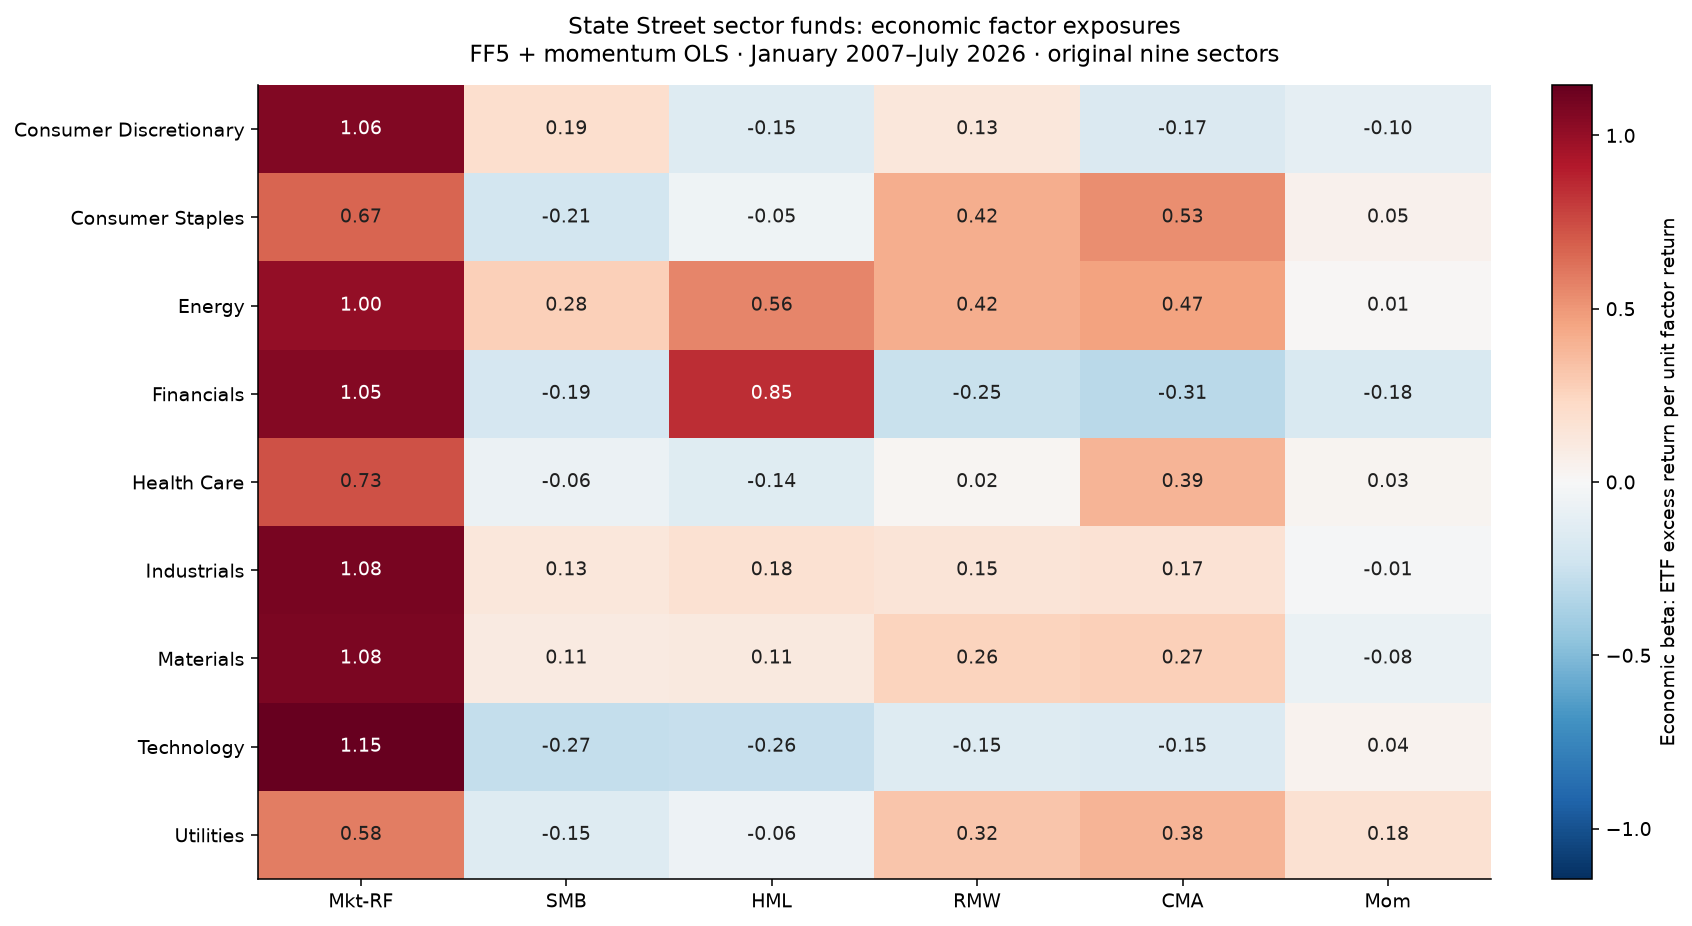

,r_squared,residual_vol_annual_pct
sector,,
Consumer Discretionary,0.855,7.448
Consumer Staples,0.653,7.326
Energy,0.532,18.185
Financials,0.887,7.519
Health Care,0.574,9.356
Industrials,0.870,6.914
Materials,0.778,9.582
Technology,0.859,7.281
Utilities,0.321,12.175


In [3]:
display(Image(filename=str(FIGURES / 'factor_map.png')))
display(pd.read_csv(RESULTS / 'exposures.csv')[['sector','r_squared','residual_vol_annual_pct']].set_index('sector').round(3))

## SVD diagnoses the problem before changing the estimator
The median rolling condition number is **2.94**, ranging from **2.42 to 3.74**. These diagnostics describe the factor design rather than the issuer's labels. In the final training window, ridge attenuates each singular direction continuously; PCR deletes two directions. Small factor variance does not imply little information about a particular ETF.

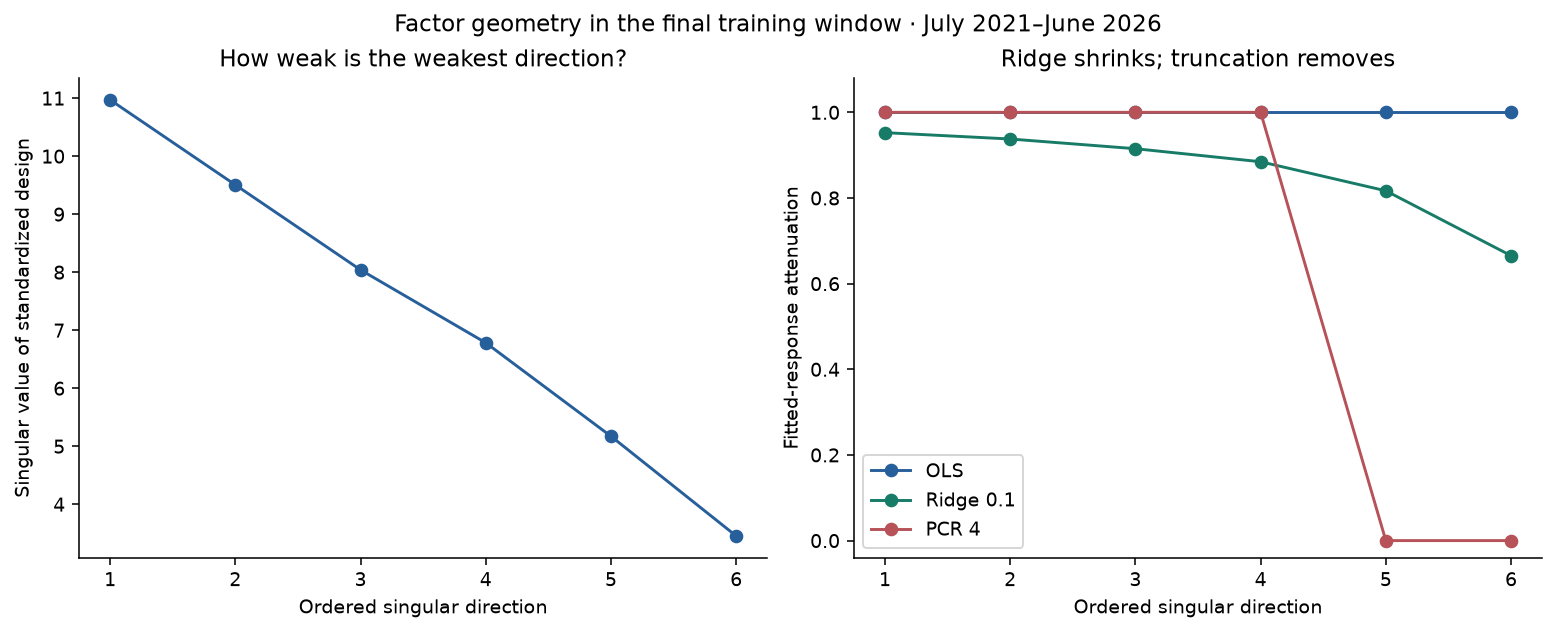

In [4]:
display(Image(filename=str(FIGURES / 'singular_geometry.png')))

## Recompute the primary comparison
The next cell fits every primary model again from the pinned inputs. The supplied factors from the target month make this conditional reconstruction, not a before-month prediction.

In [5]:
from research.run_study import rolling_reconstruction, comparison, summarize
paths = rolling_reconstruction(x, y)
head = comparison(paths)
recorded = json.loads((RESULTS / 'headline.json').read_text())
for key in ['estimate','lower95','upper95','relative_mse_reduction_pct']:
    assert np.isclose(head[key], recorded[key], rtol=1e-10, atol=1e-12)
display(summarize(paths).round(4))
display(pd.Series({k: head[k] for k in ['estimate','lower95','upper95','n']}).to_frame('Paired MSE difference (pp²)'))

,model,months,etfs,rmse_pct_monthly,mse_pp2,rms_beta_monthly_change,mean_effective_df_including_intercept
0,Market,175,9,3.4769,12.0887,0.0094,2.000
1,FF5,175,9,3.0371,9.2243,0.0412,6.000
2,OLS,175,9,3.0368,9.2219,0.0436,7.000
3,Ridge 0.1,175,9,3.0025,9.0153,0.0348,6.153
4,PCR 4,175,9,3.3216,11.0331,0.0881,5.000


,Paired MSE difference (pp²)
estimate,-0.206653
lower95,-0.425645
upper95,-0.014282
n,175.000000


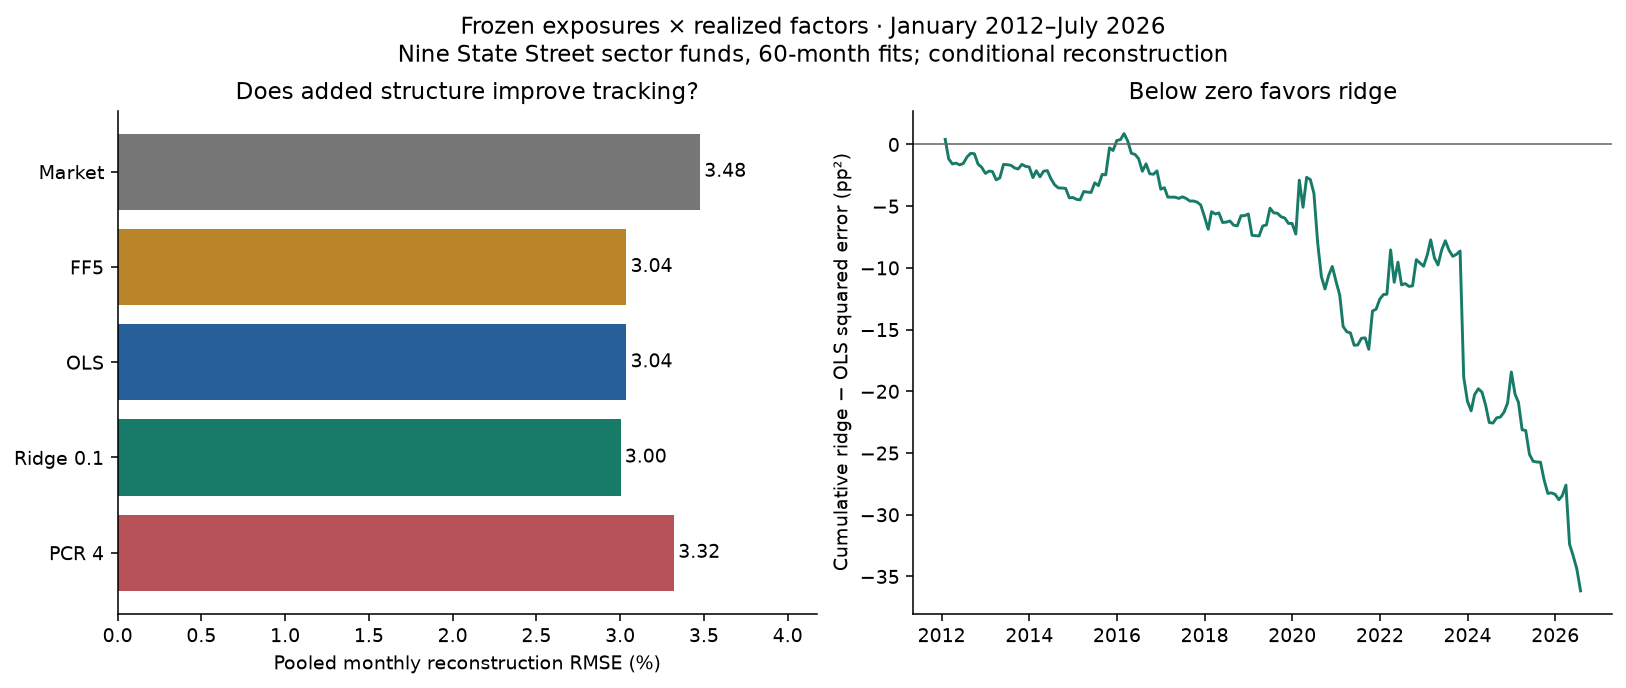

In [6]:
display(Image(filename=str(FIGURES / 'reconstruction.png')))

## Coefficient stability and reconstruction accuracy are different
Compare the measured RMS change in all six economic betas with reconstruction error. Shrinkage may reduce coefficient movement, while PCR's truncated subspace can itself move between fits. Neither smoothness nor explained factor variance is sufficient evidence of better attribution. The Technology example retains actual historical changes to the fund's composition.

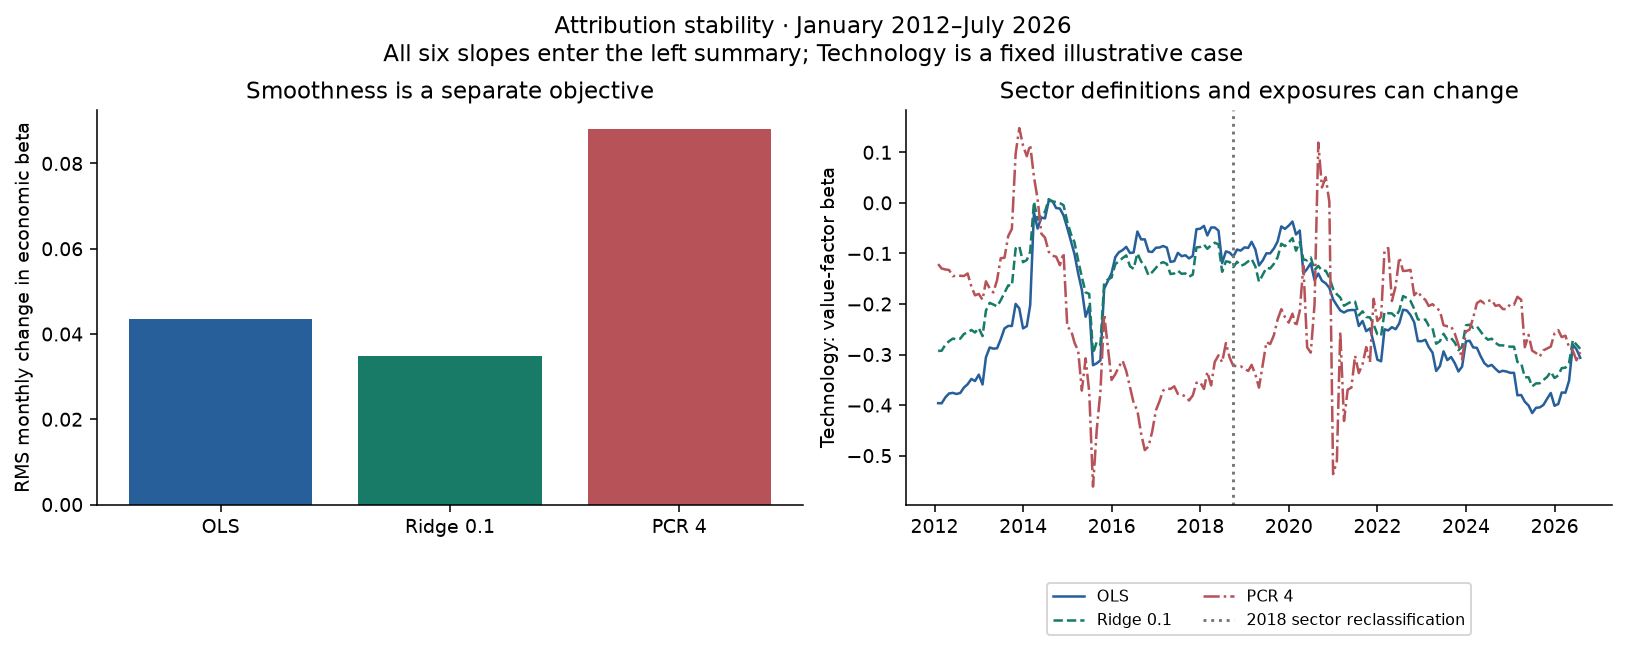

In [7]:
display(Image(filename=str(FIGURES / 'stability.png')))

## Residual means and uncertainty
The intervals are six-lag HAC, pointwise and normal-approximation. **0 of 9** primary-panel intercepts have Holm-adjusted p-values below 5%. The testing family contains these 9 descriptive intercepts. Rejection remains model-relative, and non-rejection does not prove zero alpha; precision, omitted factors and changing betas matter.

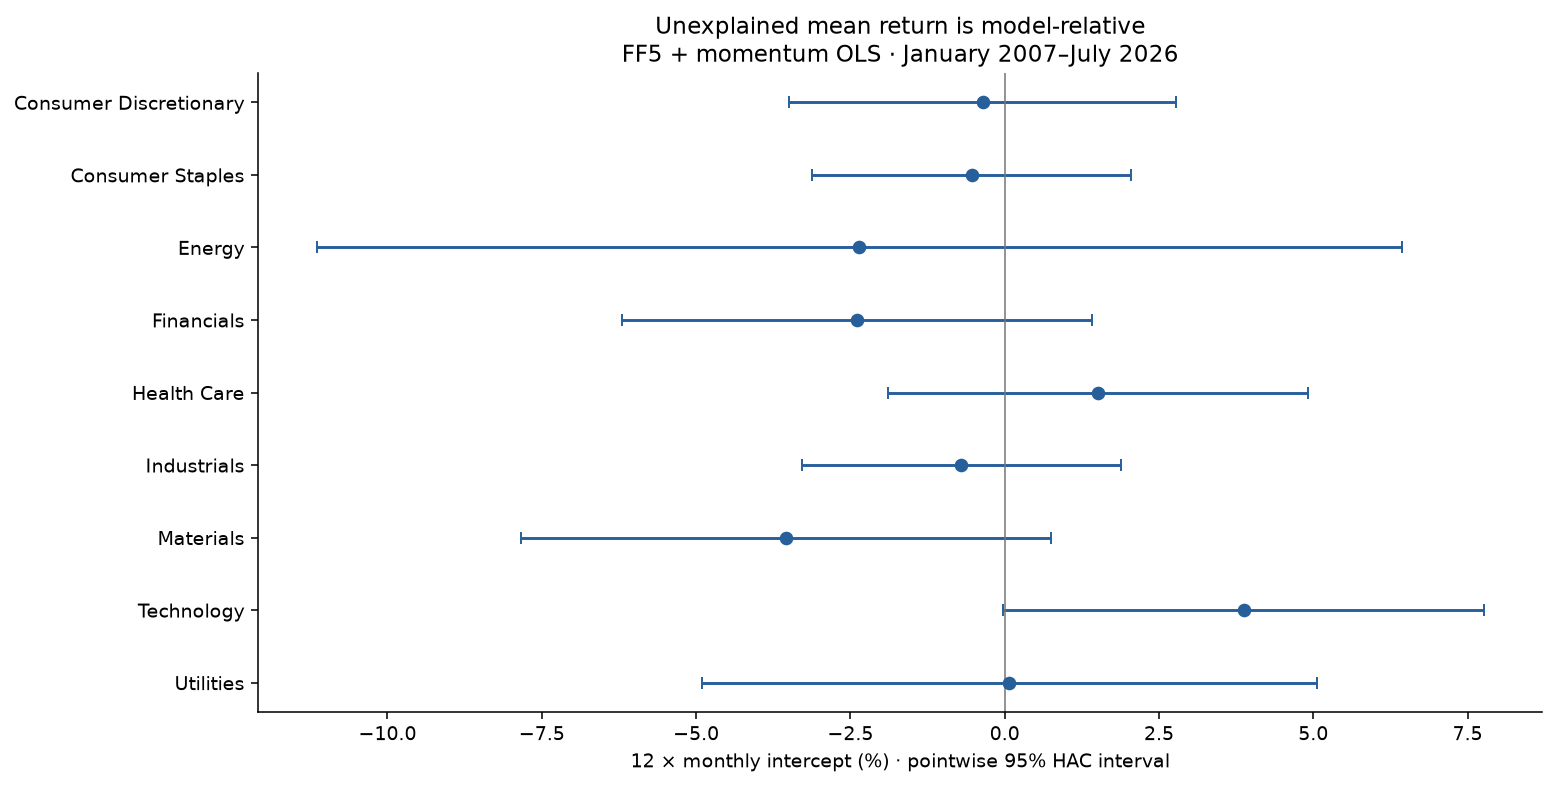

,alpha_arithmetic_annual_pct,lower95_arithmetic_annual_pct,upper95_arithmetic_annual_pct,holm_p_value
sector,,,,
Consumer Discretionary,-0.353,-3.487,2.780,1.000
Consumer Staples,-0.536,-3.127,2.054,1.000
Energy,-2.355,-11.149,6.440,1.000
Financials,-2.397,-6.205,1.411,1.000
Health Care,1.507,-1.897,4.911,1.000
Industrials,-0.706,-3.288,1.877,1.000
Materials,-3.546,-7.840,0.748,0.845
Technology,3.870,-0.025,7.765,0.463
Utilities,0.077,-4.909,5.062,1.000


In [8]:
display(Image(filename=str(FIGURES / 'alpha_intervals.png')))
display(pd.read_csv(RESULTS / 'alpha.csv')[['sector','alpha_arithmetic_annual_pct','lower95_arithmetic_annual_pct','upper95_arithmetic_annual_pct','holm_p_value']].set_index('sector').round(3))

## Sensitivities without choosing a winner
Keep the stronger and weaker penalties, all retained ranks, and windows on common dates. Each favorable or unfavorable sensitivity remains supporting evidence; it does not rewrite the fixed primary comparison.

In [9]:
display(pd.read_csv(RESULTS / 'estimator_sensitivity.csv').round(4))
windows = pd.read_csv(RESULTS / 'window_sensitivity.csv')
display(windows[windows.scope.eq('common dates')][['window','estimate','lower95','upper95','relative_mse_reduction_pct']].round(4))

,model,months,etfs,rmse_pct_monthly,mse_pp2,rms_beta_monthly_change,mean_effective_df_including_intercept
0,Market,175,9,3.4769,12.0887,0.0094,2.0000
1,FF5,175,9,3.0371,9.2243,0.0412,6.0000
2,OLS,175,9,3.0368,9.2219,0.0436,7.0000
3,Ridge 0.1,175,9,3.0025,9.0153,0.0348,6.1530
4,PCR 4,175,9,3.3216,11.0331,0.0881,5.0000
5,Ridge 0.01,175,9,3.0262,9.1578,0.0423,6.8963
6,Ridge 1,175,9,3.5654,12.7121,0.0193,3.6272
7,PCR 3,175,9,3.8945,15.1673,0.0555,4.0000
8,PCR 5,175,9,3.0995,9.6067,0.0902,6.0000


,window,estimate,lower95,upper95,relative_mse_reduction_pct
1,60,-0.2830,-0.5973,0.0015,2.5171
3,36,-0.5727,-1.0036,-0.1877,4.8445
5,120,-0.1701,-0.4575,0.0998,1.5451


## All eleven sectors on their common observed history
Real Estate and Communication Services have shorter ETF histories. This supplemental panel therefore uses July 2018–July 2026: 97 complete monthly returns for every sector. The map uses the same dates for all eleven funds; no earlier observations are backfilled. Its estimates cannot be compared with the long-panel map as though only the universe changed.

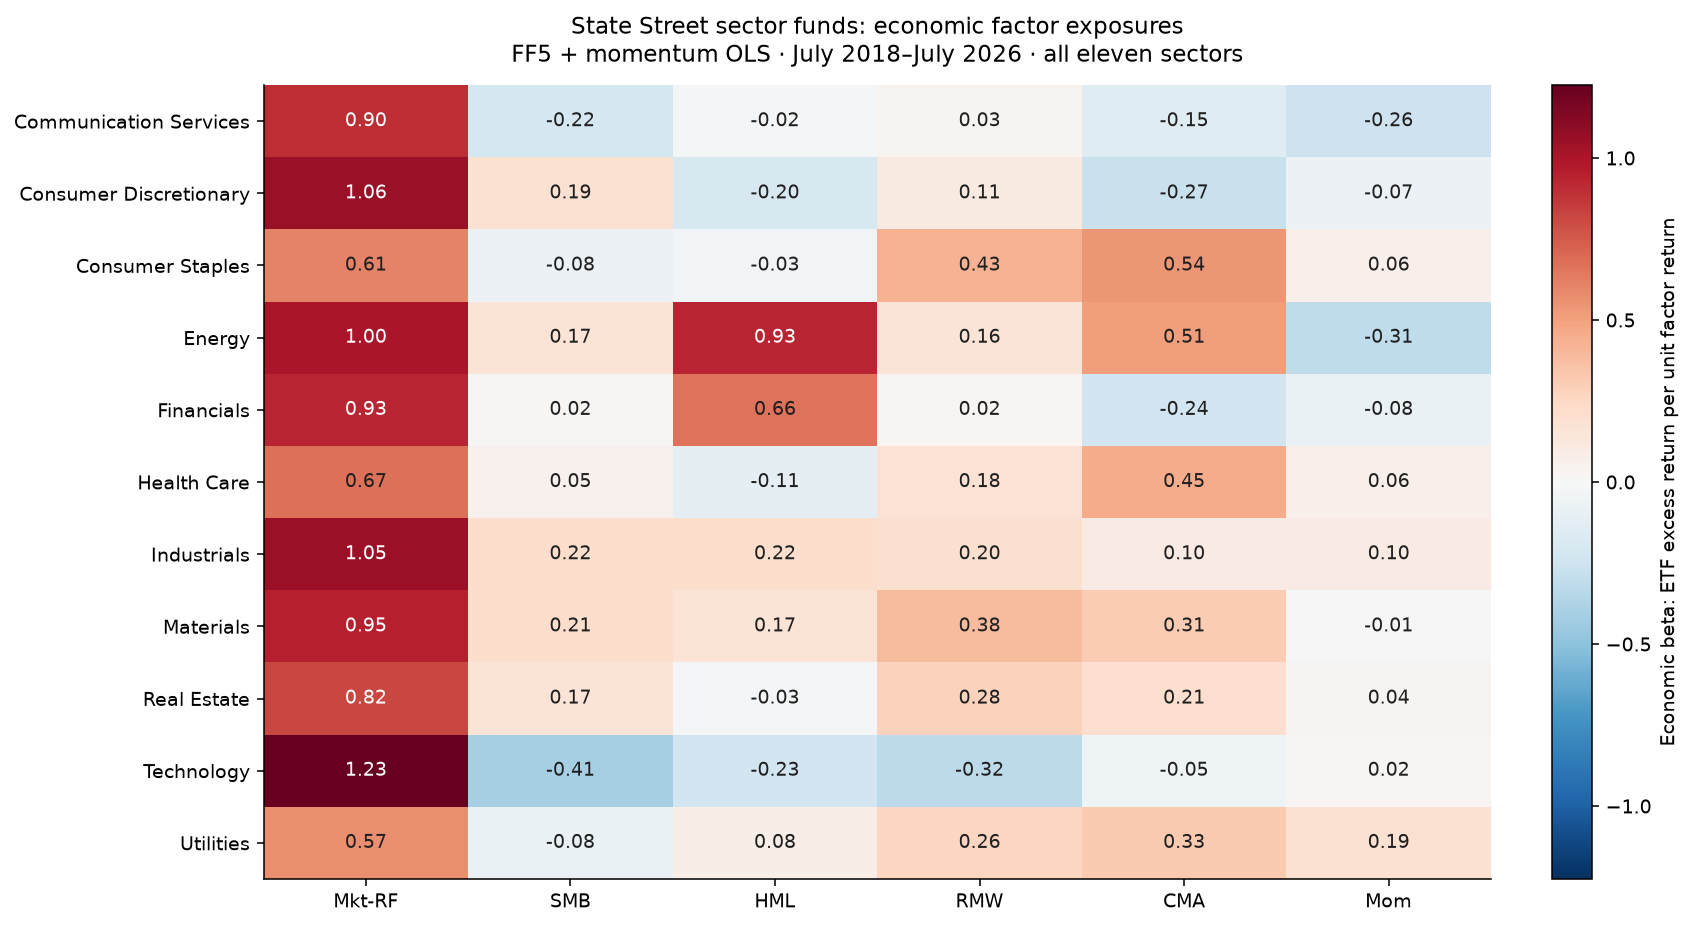

,Mkt-RF,SMB,HML,RMW,CMA,Mom
sector,,,,,,
Communication Services,0.902,-0.216,-0.015,0.034,-0.151,-0.256
Consumer Discretionary,1.058,0.187,-0.196,0.109,-0.273,-0.072
Consumer Staples,0.610,-0.075,-0.030,0.425,0.543,0.060
Energy,0.999,0.169,0.930,0.160,0.507,-0.310
Financials,0.934,0.016,0.662,0.025,-0.236,-0.080
Health Care,0.672,0.052,-0.110,0.179,0.454,0.064
Industrials,1.045,0.218,0.215,0.196,0.098,0.098
Materials,0.954,0.213,0.166,0.385,0.311,-0.006
Real Estate,0.817,0.167,-0.027,0.279,0.208,0.036


In [10]:
extended_x, extended_y, extended_audit = load_panel(extended=True)
assert len(extended_x) == 97 and extended_y.shape[1] == 11
display(Image(filename=str(FIGURES / 'extended_factor_map.png')))
display(pd.read_csv(RESULTS / 'extended_exposures.csv').drop(columns='ticker').set_index('sector').round(3))

## A shorter supplemental reconstruction window
The eleven-sector extension leaves 37 evaluation months, July 2023–July 2026, after the same 60-month fitting window. The original nine sectors are also evaluated on those same recent dates, providing a control that separates adding sectors from changing the evaluation period. The two recent-panel estimates are not directly comparable with the long-sample primary headline and do not replace it. Each panel averages sector errors; these are not portfolio allocations. There are too few observations for a 120-month fit.

In [11]:
extended_head = json.loads((RESULTS / 'extended_headline.json').read_text())
recent_nine = extended_head['recent_nine']
assert extended_head['n'] == recent_nine['n'] == 37
display(pd.read_csv(RESULTS / 'extended_summary.csv').round(4))
display(pd.DataFrame([extended_head, recent_nine], index=['All eleven sectors, recent dates', 'Original nine sectors, same recent dates'])[['estimate', 'lower95', 'upper95', 'relative_mse_reduction_pct', 'n']].rename(columns={'estimate': 'Ridge minus OLS MSE (pp²)', 'n': 'Evaluation months'}).round(4))

,model,months,etfs,rmse_pct_monthly,mse_pp2,rms_beta_monthly_change,mean_effective_df_including_intercept,universe
0,Market,37,11,3.8224,14.6105,0.0095,2.0000,All eleven sectors
1,FF5,37,11,3.6616,13.4074,0.0333,6.0000,All eleven sectors
2,OLS,37,11,3.6616,13.4070,0.0356,7.0000,All eleven sectors
3,Ridge 0.1,37,11,3.5727,12.7641,0.0268,6.1175,All eleven sectors
4,PCR 4,37,11,3.5848,12.8506,0.0311,5.0000,All eleven sectors
5,Market,37,9,3.9755,15.8047,0.0102,2.0000,Original nine on the same recent dates
6,FF5,37,9,3.7991,14.4330,0.0349,6.0000,Original nine on the same recent dates
7,OLS,37,9,3.7871,14.3420,0.0371,7.0000,Original nine on the same recent dates
8,Ridge 0.1,37,9,3.6845,13.5754,0.0278,6.1175,Original nine on the same recent dates
9,PCR 4,37,9,3.7140,13.7934,0.0319,5.0000,Original nine on the same recent dates


,Ridge minus OLS MSE (pp²),lower95,upper95,relative_mse_reduction_pct,Evaluation months
"All eleven sectors, recent dates",-0.6428,-1.0775,-0.1711,4.7949,37
"Original nine sectors, same recent dates",-0.7666,-1.3611,-0.1994,5.3453,37


## Takeaways
Ridge's reconstruction MSE is **2.24% lower** relative to OLS on the point estimate. The paired ridge-minus-OLS difference is **-0.207 pp²**, with a 95% block interval **[-0.426, -0.014]**. The paired interval supports lower reconstruction error for ridge in this panel. Use SVD to understand identification, preserve economic units, and test whether regularization earns its bias. The eleven-sector extension broadens coverage while shortening the observed history. More reliable attribution would require independent price reconciliation, dated holdings and a genuinely later evaluation period.

Explore the [five chapters](README.md#explore-the-research), [sources](research/SOURCES.md), [full evidence](docs/03-results.md), and [next experiments](research/RESEARCH_AGENDA.md).